# Stage 4b — Generalised LoRA Fine-Tuning
## Model: `meta-llama/Llama-3.2-3B-Instruct` | Dataset: CB2 (Binary Cyberbullying)
**Framework:** Generalised LoRA — Wf = W(I + UV) + AB  
**Seed:** 42 | **Primary:** Macro F1 | **Secondary:** MCC + AUC-ROC

---

## README — CB2 Protocol

### CB2 vs CB1 differences

| Setting | CB1 | CB2 |
|---|---|---|
| Classes | 6 | **2** (binary) |
| Text column | tweet_text | **Message** (capital M) |
| Label column | cyberbullying_type | **Label** (capital L) |
| Labels | string → mapped | **already 0/1 integers** |
| MAX_LENGTH | 256 | **300** (conversations longer) |
| EVAL_STEPS | 200 | **100** (fewer steps/epoch) |
| Imbalance | moderate | **1.93:1** (class weights essential) |
| Metrics | F1 + MCC | **F1 + MCC + AUC-ROC** |
| Rank sweep | r ∈ {4,8,16,32} | **r=16 only** (rank-insensitive in S2/S3) |

### CB2 Stage 2/3 references (r=16)

| Model | S2 F1 | S2 MCC | S2 AUC | S3 F1 | S3 MCC | S3 AUC |
|---|---|---|---|---|---|---|
| Llama-3B | 0.8885 | 0.7800 | 0.9650 | 0.8916 | 0.7841 | 0.9643 |
| Mistral-7B | 0.8888 | 0.7806 | 0.9664 | 0.8902 | 0.7824 | 0.9647 |
| Gemma-2-9B ★ | 0.8885 | 0.7807 | 0.9654 | **0.8948** | 0.7914 | 0.9686 |
| Phi-4 | 0.8726 | 0.7483 | 0.9544 | 0.8811 | 0.7650 | 0.9589 |
| Gemma-3-27B | 0.8837 | 0.7687 | 0.9615 | N/A (OOM) | — | — |

### CB2 rank protocol — r=4 and r=16

CB2 was rank-insensitive in Stages 2/3. However, Stage 4 CB1 revealed a consistent downward shift in optimal rank (r=32 → r=4/8/16). To test whether this pattern extends to CB2, we evaluate at both **r=4 and r=16**.

- Step 12: r=16 (default, matches S2/S3 protocol)
- Step 13: r=4 (tests rank-shift hypothesis)
- Step 14: Comparison table


---
## Step 1: Install

**After running: Runtime → Restart Runtime, then Step 2 onwards.**

In [1]:
!pip install -q \
    "transformers>=4.47.0,<4.52.0" \
    "peft>=0.14.0" \
    "bitsandbytes>=0.45.0" \
    "accelerate>=1.2.0" \
    "datasets>=3.0.0" \
    "numpy<2.1" \
    "pandas<3.0" \
    "torchvision==0.20.1" \
    "scikit-learn" \
    tqdm matplotlib seaborn

print("✓ Installation complete.")
print("\n" + "=" * 60)
print("  Restart runtime, then run from Step 2.")
print("=" * 60)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 136.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.4/906.4 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 119.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 108.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

---
## Step 2: Imports and Setup

In [1]:
import os, random, collections, re
from typing import Dict, List
import numpy as np, pandas as pd, torch, torch.nn as nn
import matplotlib.pyplot as plt, seaborn as sns

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_fscore_support,
    confusion_matrix, classification_report,
    balanced_accuracy_score, matthews_corrcoef, roc_auc_score,
)
from transformers import (
    AutoModelForSequenceClassification, AutoTokenizer,
    BitsAndBytesConfig, TrainingArguments, Trainer, TrainerCallback,
)
from peft import prepare_model_for_kbit_training, LoraConfig, get_peft_model
import bitsandbytes.functional as bnb_F
import bitsandbytes as bnb
from google.colab import drive, userdata

def set_all_seeds(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"✓ All random seeds fixed to {seed}.")

set_all_seeds(42)

HF_TOKEN = userdata.get('HF_TOKEN')
os.environ['HF_TOKEN'] = HF_TOKEN
print("✓ HF token loaded.")

drive.mount('/content/drive')
print("✓ Drive mounted.")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Device: {device}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


✓ All random seeds fixed to 42.
✓ HF token loaded.
Mounted at /content/drive
✓ Drive mounted.
✓ Device: cuda
  GPU: NVIDIA A100-SXM4-80GB
  VRAM: 85.1 GB


---
## Step 3: Global Configuration — CB2 Binary

In [2]:
MODEL_NAME   = "meta-llama/Llama-3.2-3B-Instruct"
NUM_LABELS   = 2          # Binary: 0=not_cb, 1=cyberbullying
MAX_LENGTH   = 300        # CB2 conversations — matches Stage 2/3 protocol

LORA_RANK    = 16         # Default rank
CB2_RANKS    = [16, 4]    # Test both: r=16 (S2/S3 protocol) + r=4 (rank-shift hypothesis)
LORA_ALPHA   = 16
LORA_DROPOUT = 0.05
TARGET_MODULES = ['q_proj', 'k_proj', 'v_proj', 'o_proj']

NUM_EPOCHS       = 1
LEARNING_RATE    = 2e-4
TRAIN_BATCH_SIZE = 16     # Llama-3B CB2 — confirmed safe
EVAL_BATCH_SIZE  = 32
WEIGHT_DECAY     = 0.01
EVAL_STEPS       = 100    # CB2: more frequent (fewer steps/epoch)
LOGGING_STEPS    = 50
OUTPUT_DIR       = "/content/drive/MyDrive/Results/CB2_GeneralisedLoRA_Llama3B"

CB2_PATH             = "/content/drive/MyDrive/Datasets/cb2.csv"
TRAIN_RATIO          = 0.75
TEST_RATIO           = 0.25
VAL_FROM_TRAIN       = 0.10
SIMILARITY_THRESHOLD = 0.90
RANDOM_STATE         = 42

# CB2 labels — already 0/1 integers in dataset
LABEL_MAPPING = {0: 'not_cyberbullying', 1: 'cyberbullying'}
ID2LABEL      = LABEL_MAPPING
TARGET_NAMES  = ['not_cyberbullying', 'cyberbullying']

print("✓ CB2 Configuration loaded.")
print(f"  Model     : {MODEL_NAME}")
print(f"  Task      : Binary (CB2) — 1.93:1 imbalanced")
print(f"  MAX_LENGTH: {MAX_LENGTH}")
print(f"  Metrics   : Macro F1 + MCC + AUC-ROC")
print(f"  Ranks     : {CB2_RANKS} (r=16 protocol + r=4 rank-shift test)")
print()
print("  S2 Llama CB2 r=16: F1=0.8885 | MCC=0.7800 | AUC=0.9650")
print("  S3 Llama CB2 r=16: F1=0.8916 | MCC=0.7841 | AUC=0.9643")


✓ CB2 Configuration loaded.
  Model     : meta-llama/Llama-3.2-3B-Instruct
  Task      : Binary (CB2) — 1.93:1 imbalanced
  MAX_LENGTH: 300
  Metrics   : Macro F1 + MCC + AUC-ROC
  Ranks     : [16, 4] (r=16 protocol + r=4 rank-shift test)

  S2 Llama CB2 r=16: F1=0.8885 | MCC=0.7800 | AUC=0.9650
  S3 Llama CB2 r=16: F1=0.8916 | MCC=0.7841 | AUC=0.9643


---
## Step 4: Text Preprocessing

In [3]:
def preprocess_text_for_llm(text, remove_hashtags=False, remove_emojis=False):
    if not isinstance(text, str): return ""
    text = re.sub(r'\bRT\s+@\w+:\s*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'http\S+|www\.\S+', '[URL]', text)
    text = re.sub(r'@\w+', '[USER]', text)
    if remove_hashtags: text = re.sub(r'#(\w+)', r'\1', text)
    if remove_emojis: text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'([!?.])\1+', r'\1', text)
    if len(text.split()) < 3: return ""
    return text
print("✓ Preprocessing function defined.")


✓ Preprocessing function defined.


---
## Step 5: Load and Clean CB2

**CB2 columns:** `Message` (capital M) | `Label` (capital L) — labels already 0/1.

In [4]:
print("═" * 60)
print("CB2 DATASET LOADING & CLEANING")
print("═" * 60)
df = pd.read_csv(CB2_PATH)
print(f"\n[1] Raw dataset: {len(df):,} samples")
print(f"    Columns: {df.columns.tolist()}")

TEXT_COL = 'Message'; LABEL_COL = 'Label'
df = df.rename(columns={TEXT_COL: 'text', LABEL_COL: 'label'})
df = df[['text', 'label']].copy()
print(f"[2] Text='{TEXT_COL}' | Label='{LABEL_COL}'")

corrupt_mask = df['text'].astype(str).str.strip().isin(['#NAME?','#REF!','#VALUE!','#N/A','nan',''])
df = df[~corrupt_mask].reset_index(drop=True)
print(f"[3] After corrupt removal: {len(df):,}")

unique_labels = sorted(df['label'].unique())
assert set(unique_labels).issubset({0, 1}), f"Unexpected labels: {unique_labels}"
df['label'] = df['label'].astype(int)
print(f"[4] Labels confirmed: {unique_labels} (0=not_cb, 1=cb)")

df['text'] = df['text'].apply(preprocess_text_for_llm)
df = df[df['text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f"[5] After preprocessing: {len(df):,}")

before = len(df)
df = df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
print(f"[6] After dedup: {len(df):,} (removed {before-len(df):,})")

before = len(df)
df = df[df['text'].str.split().str.len() >= 3].reset_index(drop=True)
print(f"[7] Final: {len(df):,}")

print("\n" + "═" * 60)
counts = df['label'].value_counts().sort_index()
for lbl, count in counts.items():
    name = ID2LABEL[lbl]
    print(f"  [{lbl}] {name:<25} {count:>6}  ({count/len(df)*100:.1f}%)")
print(f"  Imbalance: {counts[0]/counts[1]:.2f}:1")


════════════════════════════════════════════════════════════
CB2 DATASET LOADING & CLEANING
════════════════════════════════════════════════════════════

[1] Raw dataset: 90,356 samples
    Columns: ['Date', 'Time', 'User1 ID', 'User2 ID', 'Message', 'Label']
[2] Text='Message' | Label='Label'
[3] After corrupt removal: 90,356
[4] Labels confirmed: [np.int64(0), np.int64(1)] (0=not_cb, 1=cb)
[5] After preprocessing: 89,632
[6] After dedup: 89,525 (removed 107)
[7] Final: 89,525

════════════════════════════════════════════════════════════
  [0] not_cyberbullying          59002  (65.9%)
  [1] cyberbullying              30523  (34.1%)
  Imbalance: 1.93:1


---
## Step 6: Stratified Split + Near-Duplicate Check

In [5]:
train_val_df, test_df = train_test_split(
    df, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=df['label'])
print(f"[1] Train+Val: {len(train_val_df):,} | Test: {len(test_df):,}")

print(f"[2] Near-duplicate check...")
all_texts = list(train_val_df['text'].values) + list(test_df['text'].values)
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2, max_df=0.95)
tfidf_matrix = vectorizer.fit_transform(all_texts)
train_vecs = tfidf_matrix[:len(train_val_df)]
test_vecs = tfidf_matrix[len(train_val_df):]
leaked_indices = []
for start in range(0, len(test_df), 500):
    end = min(start+500, len(test_df))
    batch_sims = cosine_similarity(test_vecs[start:end], train_vecs)
    leaked_mask = batch_sims.max(axis=1) >= SIMILARITY_THRESHOLD
    leaked_indices.extend(test_df.index[start:end][leaked_mask].tolist())
print(f"    Found {len(leaked_indices)} near-duplicates")
if leaked_indices:
    leaked = test_df.loc[leaked_indices]
    test_df = test_df.drop(leaked_indices).reset_index(drop=True)
    train_val_df = pd.concat([train_val_df, leaked], ignore_index=True)
else:
    train_val_df = train_val_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)
assert len(set(train_val_df['text'].tolist()) & set(test_df['text'].tolist())) == 0
print("    ✓ No leakage.")

train_df, val_df = train_test_split(
    train_val_df, test_size=VAL_FROM_TRAIN, random_state=RANDOM_STATE, stratify=train_val_df['label'])
train_df = train_df.reset_index(drop=True); val_df = val_df.reset_index(drop=True)
print(f"[3] Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")


[1] Train+Val: 67,143 | Test: 22,382
[2] Near-duplicate check...
    Found 2036 near-duplicates
    ✓ No leakage.
[3] Train: 62,261 | Val: 6,918 | Test: 20,346


---
## Step 7: Class Weights (essential for CB2 imbalance)

In [6]:
def get_class_weights(df, label_col='label'):
    counts = df[label_col].value_counts().sort_index()
    total = len(df); n_classes = len(counts)
    weights = [total / (n_classes * counts.get(i, 1)) for i in range(n_classes)]
    weights_norm = [w / sum(weights) * n_classes for w in weights]
    print("Class weights (inverse-frequency):")
    for i, w in enumerate(weights_norm):
        print(f"  [{i}] {ID2LABEL[i]:<25} {w:.4f}")
    return weights_norm
print("✓ get_class_weights() defined.")


✓ get_class_weights() defined.


---
## Step 8: Effective Rank

In [7]:
def calculate_effective_rank_generalised(model, threshold_ratio=1e-3):
    full_ranks, uv_ranks, ab_ranks, per_layer = [], [], [], []
    skipped = 0
    for name, module in model.named_modules():
        if type(module).__name__ != 'GeneralisedLoRALayer': continue
        try:
            U = module.lora_U.data.float(); V = module.lora_V.data.float()
            A = module.lora_A.data.float(); B = module.lora_B.data.float()
            UV = U @ V; AB = A @ B
            S_uv = torch.linalg.svdvals(UV)
            r_uv = int((S_uv > threshold_ratio * S_uv[0]).sum()) if S_uv[0] > 0 else 0
            uv_ranks.append(r_uv)
            S_ab = torch.linalg.svdvals(AB)
            r_ab = int((S_ab > threshold_ratio * S_ab[0]).sum()) if S_ab[0] > 0 else 0
            ab_ranks.append(r_ab)
            weight_obj = module.inner.weight
            try:
                if hasattr(weight_obj, 'quant_state'):
                    W = bnb_F.dequantize_4bit(weight_obj.data, weight_obj.quant_state).float()
                else:
                    W = weight_obj.data.float()
            except Exception as e:
                if skipped == 0: print(f"  ℹ Dequant error: {type(e).__name__}: {e}")
                skipped += 1; continue
            if W.shape[0] == module.m and W.shape[1] == module.n: pass
            elif W.shape[0] == module.n and W.shape[1] == module.m: W = W.T.contiguous()
            else: skipped += 1; continue
            Wf = W + W @ UV + AB
            S_Wf = torch.linalg.svdvals(Wf)
            r_Wf = int((S_Wf > threshold_ratio * S_Wf[0]).sum()) if S_Wf[0] > 0 else 0
            full_ranks.append(r_Wf)
            per_layer.append({'layer': name, 'rank_Wf': r_Wf, 'rank_UV': r_uv, 'rank_AB': r_ab})
        except Exception: skipped += 1; continue
    if skipped > 0: print(f"  ℹ {skipped} layers skipped")
    return {
        "avg_eff_rank_Wf": float(np.mean(full_ranks)) if full_ranks else 0.0,
        "avg_eff_rank_UV": float(np.mean(uv_ranks)) if uv_ranks else 0.0,
        "avg_eff_rank_AB": float(np.mean(ab_ranks)) if ab_ranks else 0.0,
        "layer_count": len(full_ranks), "per_layer_ranks": per_layer,
    }
print("✓ calculate_effective_rank_generalised() defined.")


✓ calculate_effective_rank_generalised() defined.


---
## Step 9: Evaluation Metrics (CB2 — includes AUC-ROC)

In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    accuracy = accuracy_score(labels, predictions)
    _, _, f1, _ = precision_recall_fscore_support(labels, predictions, average='macro', zero_division=0)
    mcc = matthews_corrcoef(labels, predictions)
    return {"accuracy": accuracy, "f1": f1, "mcc": mcc}

def evaluate_dataset_cb2(y_true, y_pred, y_prob, dataset_name):
    """CB2 evaluation with AUC-ROC. y_prob = P(cyberbullying=1)."""
    print(f"\n{'═'*65}")
    print(f"FINAL EVALUATION — {dataset_name}")
    print(f"{'═'*65}")
    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    bal_accuracy = balanced_accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    try:
        auc_roc = roc_auc_score(y_true, y_prob)
    except Exception:
        auc_roc = 0.0
    print(f"  Accuracy          : {accuracy:.4f}")
    print(f"  Macro F1          : {macro_f1:.4f}  ← PRIMARY")
    print(f"  Weighted F1       : {weighted_f1:.4f}")
    print(f"  Balanced Accuracy : {bal_accuracy:.4f}")
    print(f"  MCC               : {mcc:.4f}  ← SECONDARY")
    print(f"  AUC-ROC           : {auc_roc:.4f}  ← SECONDARY")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred, labels=[0,1],
                                target_names=TARGET_NAMES, zero_division=0, digits=4))
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES)
    axes[0].set_title(f'Counts — {dataset_name}')
    axes[0].tick_params(axis='x', rotation=45)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES, vmin=0, vmax=1)
    axes[1].set_title(f'Normalised — {dataset_name}')
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/confusion_matrix_{dataset_name.replace(' ','_')}.png", dpi=150, bbox_inches='tight')
    plt.show()
    return {'accuracy': accuracy, 'macro_f1': macro_f1, 'weighted_f1': weighted_f1,
            'balanced_accuracy': bal_accuracy, 'mcc': mcc, 'auc_roc': auc_roc}

def make_predictions_cb2(model, df_test, tokenizer, batch_size=32):
    """Returns predictions AND probabilities for AUC-ROC."""
    model.eval()
    all_preds, all_probs = [], []
    texts = df_test['text'].tolist()
    dev = next(model.parameters()).device
    for start in range(0, len(texts), batch_size):
        enc = tokenizer(texts[start:start+batch_size], padding='max_length',
                        truncation=True, max_length=MAX_LENGTH, return_tensors='pt').to(dev)
        with torch.no_grad():
            logits = model(**enc).logits
        probs = torch.softmax(logits.float(), dim=-1)
        all_preds.extend(torch.argmax(logits, dim=-1).cpu().numpy().tolist())
        all_probs.extend(probs[:, 1].cpu().numpy().tolist())  # P(cyberbullying=1)
    return all_preds, all_probs

print("✓ compute_metrics(), evaluate_dataset_cb2(), make_predictions_cb2() defined.")
print("  CB2: includes AUC-ROC via softmax probabilities.")


✓ compute_metrics(), evaluate_dataset_cb2(), make_predictions_cb2() defined.
  CB2: includes AUC-ROC via softmax probabilities.


---
## Step 10: Stability System + Custom Trainer

In [9]:
class StabilityCallback(TrainerCallback):
    def __init__(self):
        self.train_losses = []; self.val_metrics = collections.defaultdict(list); self.val_steps = []
    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs or state.global_step == 0: return
        if 'loss' in logs: self.train_losses.append((state.global_step, float(logs['loss'])))
    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if not metrics: return
        self.val_steps.append(state.global_step)
        for k, v in metrics.items(): self.val_metrics[k.replace('eval_','')].append(float(v))
    def get_stability_report(self):
        report = {}
        if self.train_losses:
            arr = np.array([l for (_,l) in self.train_losses])
            report['loss_mean_overall'] = float(np.mean(arr))
            report['loss_std_overall'] = float(np.std(arr))
            report['loss_cv_overall'] = float(np.std(arr)/np.mean(arr)) if np.mean(arr) > 0 else 0.0
        for m, vals in self.val_metrics.items():
            if len(vals) > 1:
                a = np.array(vals)
                report[f'val_{m}_std'] = float(np.std(a))
                report[f'val_{m}_best'] = float(a.max())
        report['stability_score'] = round((report.get('loss_cv_overall',0)*0.5) + (report.get('val_f1_std',0)*0.5), 6)
        return report
    def plot_stability_curves(self, stage_label='Stage 4', save_path=None):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        if self.train_losses:
            steps = [s for (s,_) in self.train_losses]; losses = [l for (_,l) in self.train_losses]
            ax1.plot(steps, losses, color='steelblue', linewidth=0.7, alpha=0.5, label='Step loss')
            w = min(20, len(losses))
            if len(losses) >= w:
                roll = np.convolve(losses, np.ones(w)/w, mode='valid')
                ax1.plot(steps[w-1:], roll, color='navy', linewidth=2.2, label=f'Rolling mean (w={w})')
            ax1.set_title(f'{stage_label}\nTraining Loss'); ax1.set_xlabel('Step'); ax1.set_ylabel('Loss')
            ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)
        if self.val_steps and 'f1' in self.val_metrics:
            f1v = self.val_metrics['f1']
            ax2.plot(self.val_steps, f1v, 'o-', color='forestgreen', linewidth=2, markersize=5, label='Macro F1')
            if 'mcc' in self.val_metrics:
                ax2r = ax2.twinx()
                ax2r.plot(self.val_steps, self.val_metrics['mcc'], 's--', color='darkorange',
                          linewidth=1.5, markersize=4, label='MCC', alpha=0.8)
                ax2r.set_ylabel('MCC', color='darkorange')
                l1, lb1 = ax2.get_legend_handles_labels()
                l2, lb2 = ax2r.get_legend_handles_labels()
                ax2.legend(l1+l2, lb1+lb2, fontsize=9)
            ax2.set_title(f'{stage_label}\nValidation Metrics'); ax2.set_xlabel('Step')
            ax2.set_ylabel('Macro F1', color='forestgreen'); ax2.grid(True, alpha=0.3)
        plt.tight_layout()
        if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

class CustomTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = torch.tensor(class_weights, dtype=torch.float32) if class_weights is not None else None
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels"); outputs = model(**inputs); logits = outputs.logits
        loss_fn = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device)) if self.class_weights is not None else nn.CrossEntropyLoss()
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

print("✓ StabilityCallback, CustomTrainer defined.")


✓ StabilityCallback, CustomTrainer defined.


---
## Step 11: Generalised LoRA + Training Function (CB2)

In [10]:
class GeneralisedLoRALayer(nn.Module):
    def __init__(self, base_layer, rank, dropout=0.05, alpha=None):
        super().__init__()
        self.rank = rank
        self.alpha = alpha if alpha is not None else rank
        self.scaling = self.alpha / self.rank
        inner = base_layer.base_layer if hasattr(base_layer, 'base_layer') else base_layer
        if hasattr(inner, 'in_features'):
            n, m = inner.in_features, inner.out_features
        elif hasattr(inner, 'weight'):
            n, m = inner.weight.shape[1], inner.weight.shape[0]
        else:
            raise ValueError(f"Cannot determine dims from {type(inner)}")
        self.n = n; self.m = m; self.inner = inner
        _dev = self.inner.weight.device
        self.lora_U = nn.Parameter(torch.empty(n, rank, device=_dev))
        self.lora_V = nn.Parameter(torch.zeros(rank, n, device=_dev))
        self.lora_A = nn.Parameter(torch.empty(m, rank, device=_dev))
        self.lora_B = nn.Parameter(torch.zeros(rank, n, device=_dev))
        nn.init.normal_(self.lora_U, mean=0.0, std=0.01)
        nn.init.normal_(self.lora_A, mean=0.0, std=0.01)
        self.dropout = nn.Dropout(p=dropout) if dropout > 0.0 else nn.Identity()
        for param in self.inner.parameters(): param.requires_grad = False

    def forward(self, x):
        base_out = self.inner(x)
        x_drop = self.dropout(x)
        lora_vx = x_drop @ self.lora_V.T
        lora_uvx = lora_vx @ self.lora_U.T
        mult_out = self.inner(lora_uvx)
        lora_bx = x_drop @ self.lora_B.T
        add_out = lora_bx @ self.lora_A.T
        return base_out + self.scaling * mult_out + self.scaling * add_out


def apply_generalised_lora_over_peft(model, target_modules, rank, dropout=0.05, alpha=None):
    from peft.tuners.lora import LoraLayer
    if alpha is None: alpha = rank
    replaced = 0
    module_dict = dict(model.named_modules())
    for name, module in list(model.named_modules()):
        if not isinstance(module, LoraLayer): continue
        if not any(name.endswith(f'.{t}') or name == t for t in target_modules): continue
        parts = name.rsplit('.', 1)
        if len(parts) == 2:
            parent = module_dict.get(parts[0])
            if parent is None: continue
            attr_name = parts[1]
        else:
            parent = model; attr_name = name
        setattr(parent, attr_name, GeneralisedLoRALayer(module, rank=rank, dropout=dropout, alpha=alpha))
        replaced += 1
    print(f"  ✓ Replaced {replaced} PEFT LoraLayers with GeneralisedLoRALayer")
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return model, trainable, total


def run_generalised_lora_cb2(train_df, val_df, test_df, lora_rank=16):
    """Train and evaluate Generalised LoRA on CB2. r=16 only (no sweep)."""
    set_all_seeds(RANDOM_STATE)
    lora_alpha = lora_rank
    label = f'GeneralisedLoRA_r{lora_rank}'

    print(f'\n{"="*65}')
    print(f'  STAGE 4b — GENERALISED LoRA CB2  |  {MODEL_NAME}')
    print(f'  Rank: {lora_rank}  |  Formula: Wf = W(I + UV) + AB')
    print(f'  Binary: 0=not_cb | 1=cyberbullying | 1.93:1 imbalanced')
    print(f'{"="*65}')

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    run_dir = os.path.join(OUTPUT_DIR, label)
    os.makedirs(run_dir, exist_ok=True)

    print('\n[1] Loading tokenizer...')
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, token=HF_TOKEN)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        tokenizer.pad_token_id = tokenizer.eos_token_id

    def tokenise(examples):
        return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=MAX_LENGTH)

    print('[2] Preparing datasets...')
    train_m = train_df.copy(); val_m = val_df.copy(); test_m = test_df.copy()
    # CB2 labels already 0/1 integers — no mapping needed
    hf_train = Dataset.from_pandas(train_m[['text','label']].reset_index(drop=True)).map(tokenise, batched=True, remove_columns=['text'])
    hf_val = Dataset.from_pandas(val_m[['text','label']].reset_index(drop=True)).map(tokenise, batched=True, remove_columns=['text'])
    hf_train.set_format('torch'); hf_val.set_format('torch')
    print(f'   Train: {len(hf_train):,} | Val: {len(hf_val):,} | Test: {len(test_m):,}')

    quant_config = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_quant_type='nf4',
        bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype=torch.bfloat16)
    lora_config = LoraConfig(
        r=lora_rank, lora_alpha=lora_rank, target_modules=TARGET_MODULES,
        lora_dropout=LORA_DROPOUT, bias='none', task_type='SEQ_CLS')

    print('[3] Loading model...')
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, quantization_config=quant_config, num_labels=NUM_LABELS,
        torch_dtype=torch.bfloat16, device_map='auto', token=HF_TOKEN)
    model.config.pad_token_id = tokenizer.pad_token_id
    model.config.use_cache = False
    model = prepare_model_for_kbit_training(model)
    model = get_peft_model(model, lora_config)

    print('[4] Injecting GeneralisedLoRALayer...')
    model, trainable, total = apply_generalised_lora_over_peft(
        model, TARGET_MODULES, rank=lora_rank, dropout=LORA_DROPOUT, alpha=lora_rank)
    print(f'   Trainable: {trainable:,} | Total: {total:,} | {100*trainable/total:.4f}%')

    class_weights = get_class_weights(train_df)

    training_args = TrainingArguments(
        output_dir=run_dir, num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
        eval_strategy='steps', eval_steps=EVAL_STEPS,
        logging_steps=LOGGING_STEPS, save_strategy='no',
        fp16=False, bf16=True, report_to='none', remove_unused_columns=False)

    stability_cb = StabilityCallback()
    trainer = CustomTrainer(
        model=model, args=training_args,
        train_dataset=hf_train, eval_dataset=hf_val,
        compute_metrics=compute_metrics, callbacks=[stability_cb],
        class_weights=class_weights)

    print(f'\n[5] Training...')
    train_result = trainer.train()
    train_runtime_s = train_result.metrics.get('train_runtime', 0)
    print(f'   Time: {train_runtime_s:.0f}s ({train_runtime_s/3600:.2f} hrs)')

    stab_report = stability_cb.get_stability_report()
    stab_score = stab_report.get('stability_score', float('nan'))
    print(f'   Stability: {stab_score:.4f}')

    stability_cb.plot_stability_curves(
        stage_label=f'Stage 4b CB2 — Llama-3B (r={lora_rank})',
        save_path=os.path.join(run_dir, f'stability_{label}.png'))

    print('\n[6] Computing effective rank...')
    rank_info = calculate_effective_rank_generalised(model)
    print(f'   Eff.Rank Wf: {rank_info["avg_eff_rank_Wf"]:.2f}  (r={lora_rank})')
    print(f'   Layers: {rank_info["layer_count"]}')

    print('\n[7] Evaluating on test set...')
    y_pred, y_prob = make_predictions_cb2(model, test_m, tokenizer)
    y_true = test_m['label'].tolist()
    eval_results = evaluate_dataset_cb2(y_true, y_pred, y_prob, f'Stage4b_CB2_{label}')

    # Save CSV
    row = {
        'model': 'Llama-3.2-3B', 'stage': '4b', 'formula': 'Wf=W(I+UV)+AB',
        'dataset': 'CB2', 'rank': lora_rank, 'trainable_params': trainable,
        'macro_f1': eval_results['macro_f1'], 'mcc': eval_results['mcc'],
        'auc_roc': eval_results['auc_roc'],
        'accuracy': eval_results['accuracy'],
        'avg_eff_rank_Wf': rank_info['avg_eff_rank_Wf'],
        'stability_score': stab_score, 'train_runtime_s': train_runtime_s,
    }
    pd.DataFrame([row]).to_csv(os.path.join(run_dir, f'{label}_results.csv'), index=False)
    print(f'\n✓ Results saved → {run_dir}')

    del model, trainer; torch.cuda.empty_cache()

    return {**eval_results, **rank_info, 'stability_score': stab_score,
            'train_runtime_s': train_runtime_s, 'trainable_params': trainable}


print("✓ GeneralisedLoRALayer, run_generalised_lora_cb2() defined.")
print("  CB2 protocol: r=16 only, MAX_LENGTH=300, AUC-ROC included.")


✓ GeneralisedLoRALayer, run_generalised_lora_cb2() defined.
  CB2 protocol: r=16 only, MAX_LENGTH=300, AUC-ROC included.


---
## Step 12: Execute — r=16 (default)

**Expected time:** ~4–5 hrs  
**S2 r=16:** F1=0.8885 | MCC=0.7800 | AUC=0.9650  
**S3 r=16:** F1=0.8916 | MCC=0.7841 | AUC=0.9643


✓ All random seeds fixed to 42.

  STAGE 4b — GENERALISED LoRA CB2  |  meta-llama/Llama-3.2-3B-Instruct
  Rank: 16  |  Formula: Wf = W(I + UV) + AB
  Binary: 0=not_cb | 1=cyberbullying | 1.93:1 imbalanced

[1] Loading tokenizer...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

[2] Preparing datasets...


...

[4] Injecting GeneralisedLoRALayer...
  ✓ Replaced 112 PEFT LoraLayers with GeneralisedLoRALayer
   Trainable: 20,191,232 | Total: 1,823,661,056 | 1.1072%
Class weights (inverse-frequency):
  [0] not_cyberbullying         0.6967
  [1] cyberbullying             1.3033

[5] Training...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
100,0.417900,0.428169,0.862966,0.845568,0.693345
200,0.408000,0.297537,0.871784,0.862878,0.730351
300,0.340400,0.352728,0.826250,0.821943,0.682285
400,0.347000,0.291512,0.884649,0.872743,0.745500
500,0.329500,0.297776,0.882480,0.870813,0.741642
600,0.375600,0.286161,0.882047,0.873004,0.748671
700,0.347200,0.326524,0.885082,0.870478,0.743260
800,0.320400,0.327194,0.884649,0.869631,0.742119
900,0.314200,0.280220,0.878144,0.870671,0.749068
1000,0.300300,0.270556,0.877855,0.869975,0.746347


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/

   Time: 8930s (2.48 hrs)
   Stability: 0.0999


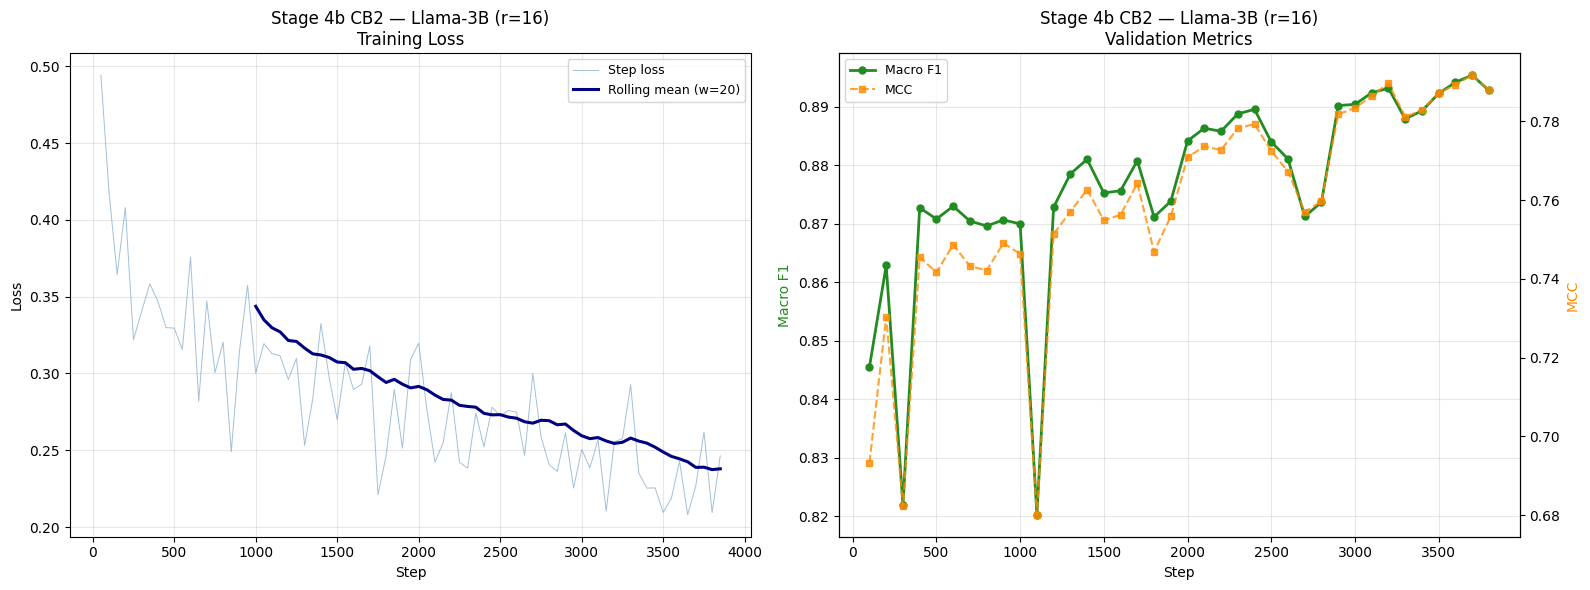


[6] Computing effective rank...
   Eff.Rank Wf: 2030.21  (r=16)
   Layers: 112

[7] Evaluating on test set...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — Stage4b_CB2_GeneralisedLoRA_r16
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9017
  Macro F1          : 0.8896  ← PRIMARY
  Weighted F1       : 0.9031
  Balanced Accuracy : 0.9023
  MCC               : 0.7823  ← SECONDARY
  AUC-ROC           : 0.9657  ← SECONDARY

  Classification Report:
                   precision    recall  f1-score   support

not_cyberbullying     0.9530    0.9007    0.9262     13923
    cyberbullying     0.8077    0.9038    0.8530      6423

         accuracy                         0.9017     20346
        macro avg     0.8804    0.9023    0.8896     20346
     weighted avg     0.9072    0.9017    0.9031     20346



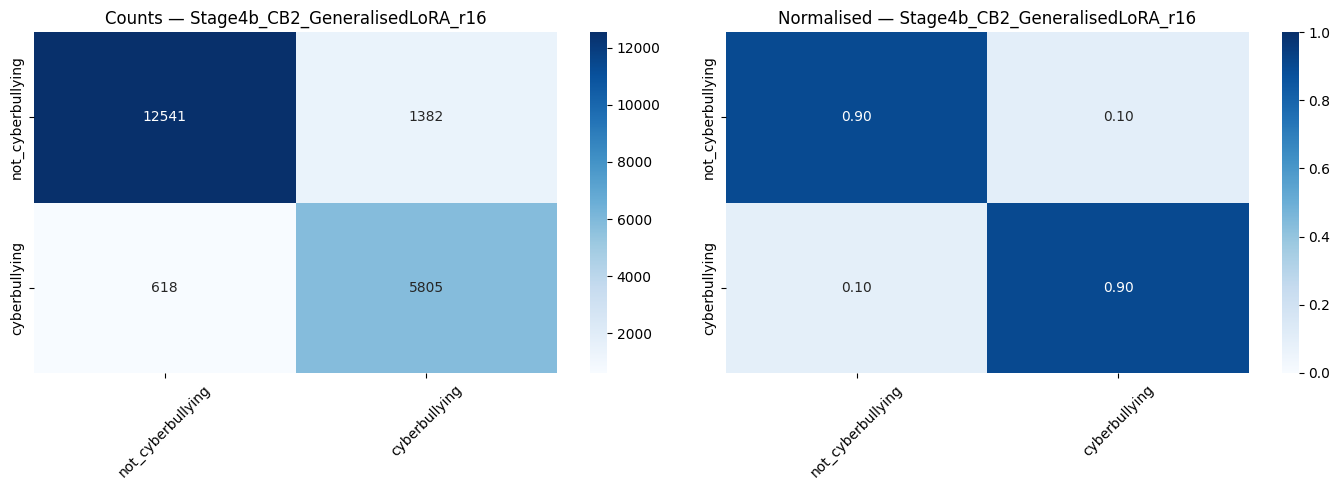


✓ Results saved → /content/drive/MyDrive/Results/CB2_GeneralisedLoRA_Llama3B/GeneralisedLoRA_r16

═════════════════════════════════════════════════════════════════
  STAGE 4b CB2 — Llama-3B r=16
═════════════════════════════════════════════════════════════════
  Macro F1   : 0.8896   ← PRIMARY
  MCC        : 0.7823
  AUC-ROC    : 0.9657
  Δ vs S2    : +0.0011 F1
  Δ vs S3    : -0.0020 F1

  → Step 13 runs r=4 next.


In [11]:
# ════════════════════════════════════════════════════════════════════════════
# STEP 12: CB2 Llama-3B — r=16 (default, matches S2/S3 protocol)
# ════════════════════════════════════════════════════════════════════════════

results_r16 = run_generalised_lora_cb2(train_df=train_df, val_df=val_df, test_df=test_df, lora_rank=16)

print('\n' + '═'*65)
print('  STAGE 4b CB2 — Llama-3B r=16')
print('═'*65)
print(f'  Macro F1   : {results_r16["macro_f1"]:.4f}   ← PRIMARY')
print(f'  MCC        : {results_r16["mcc"]:.4f}')
print(f'  AUC-ROC    : {results_r16["auc_roc"]:.4f}')
print(f'  Δ vs S2    : {results_r16["macro_f1"]-0.8885:+.4f} F1')
print(f'  Δ vs S3    : {results_r16["macro_f1"]-0.8916:+.4f} F1')
print('\n  → Step 13 runs r=4 next.')


---
## Step 13: Execute — r=4 (rank-shift hypothesis test)

Stage 4 CB1 showed optimal rank shifting downward (r=32 → r=4 for Gemma-2-9B).  
Does the same pattern hold on CB2?


✓ All random seeds fixed to 42.

  STAGE 4b — GENERALISED LoRA CB2  |  meta-llama/Llama-3.2-3B-Instruct
  Rank: 4  |  Formula: Wf = W(I + UV) + AB
  Binary: 0=not_cb | 1=cyberbullying | 1.93:1 imbalanced

[1] Loading tokenizer...
[2] Preparing datasets...


Map:   0%|          | 0/62261 [00:00<?, ? examples/s]

Map:   0%|          | 0/6918 [00:00<?, ? examples/s]

   Train: 62,261 | Val: 6,918 | Test: 20,346
[3] Loading model...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

...

Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
100,0.424200,0.341104,0.861376,0.849345,0.699535
200,0.412400,0.301277,0.869760,0.861650,0.730535
300,0.327200,0.308028,0.862243,0.855701,0.726762
400,0.337600,0.276541,0.879734,0.870428,0.743347
500,0.303700,0.361288,0.826106,0.821770,0.681711
600,0.363900,0.281389,0.877710,0.870429,0.749398
700,0.356000,0.396294,0.872507,0.851574,0.715015
800,0.314000,0.354780,0.880023,0.862946,0.731372
900,0.279500,0.274088,0.872651,0.865708,0.742493
1000,0.280800,0.280755,0.872796,0.865645,0.741441


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/

Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
100,0.424200,0.341104,0.861376,0.849345,0.699535
200,0.412400,0.301277,0.869760,0.861650,0.730535
300,0.327200,0.308028,0.862243,0.855701,0.726762
400,0.337600,0.276541,0.879734,0.870428,0.743347
500,0.303700,0.361288,0.826106,0.821770,0.681711
600,0.363900,0.281389,0.877710,0.870429,0.749398
700,0.356000,0.396294,0.872507,0.851574,0.715015
800,0.314000,0.354780,0.880023,0.862946,0.731372
900,0.279500,0.274088,0.872651,0.865708,0.742493
1000,0.280800,0.280755,0.872796,0.865645,0.741441


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/

   Time: 9058s (2.52 hrs)
   Stability: 0.1038


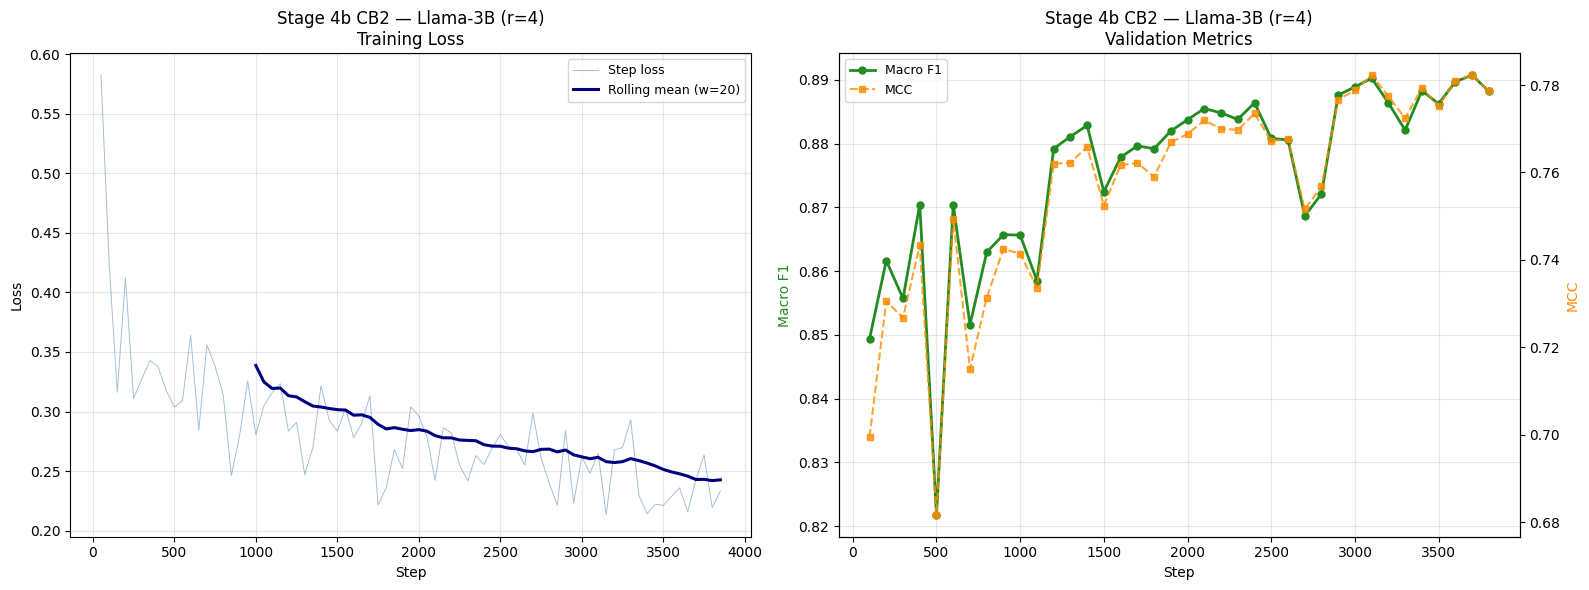


[6] Computing effective rank...
   Eff.Rank Wf: 2030.64  (r=4)
   Layers: 112

[7] Evaluating on test set...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — Stage4b_CB2_GeneralisedLoRA_r4
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.8978
  Macro F1          : 0.8857  ← PRIMARY
  Weighted F1       : 0.8994
  Balanced Accuracy : 0.9001
  MCC               : 0.7755  ← SECONDARY
  AUC-ROC           : 0.9644  ← SECONDARY

  Classification Report:
                   precision    recall  f1-score   support

not_cyberbullying     0.9539    0.8939    0.9229     13923
    cyberbullying     0.7976    0.9063    0.8485      6423

         accuracy                         0.8978     20346
        macro avg     0.8757    0.9001    0.8857     20346
     weighted avg     0.9045    0.8978    0.8994     20346



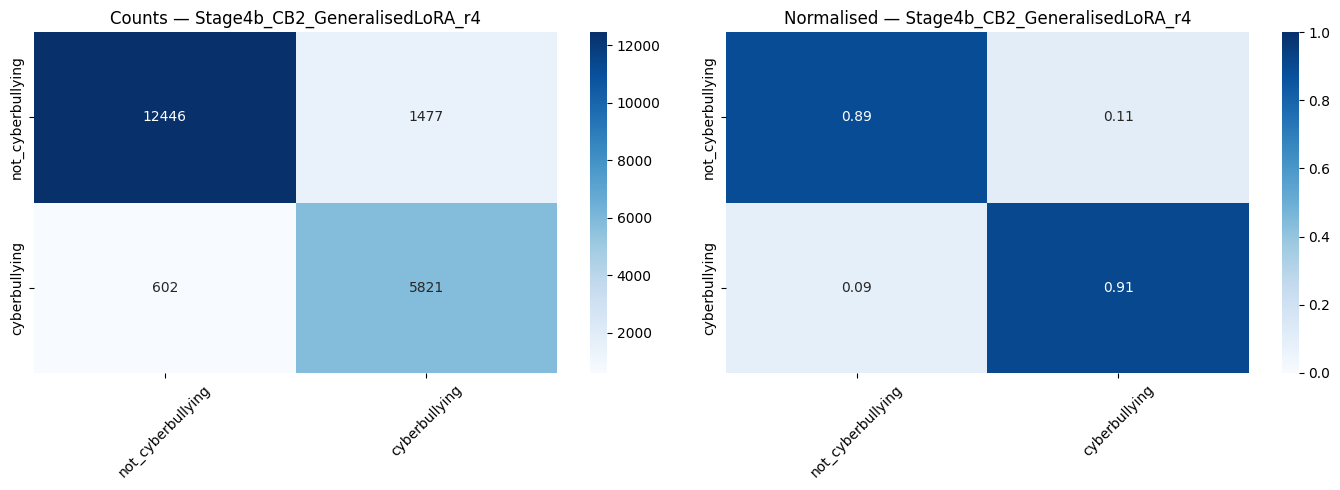


✓ Results saved → /content/drive/MyDrive/Results/CB2_GeneralisedLoRA_Llama3B/GeneralisedLoRA_r4

═════════════════════════════════════════════════════════════════
  STAGE 4b CB2 — Llama-3B r=4
═════════════════════════════════════════════════════════════════
  Macro F1   : 0.8857
  MCC        : 0.7755
  AUC-ROC    : 0.9644
  Δ vs r=16  : -0.0039 F1

  ≈ r=4 ≈ r=16 — CB2 remains rank-insensitive in Stage 4


In [12]:
# ════════════════════════════════════════════════════════════════════════════
# STEP 13: CB2 Llama-3B — r=4 (rank-shift hypothesis)
# ════════════════════════════════════════════════════════════════════════════

results_r4 = run_generalised_lora_cb2(train_df=train_df, val_df=val_df, test_df=test_df, lora_rank=4)

print('\n' + '═'*65)
print('  STAGE 4b CB2 — Llama-3B r=4')
print('═'*65)
print(f'  Macro F1   : {results_r4["macro_f1"]:.4f}')
print(f'  MCC        : {results_r4["mcc"]:.4f}')
print(f'  AUC-ROC    : {results_r4["auc_roc"]:.4f}')
print(f'  Δ vs r=16  : {results_r4["macro_f1"]-results_r16["macro_f1"]:+.4f} F1')
print()
if results_r4["macro_f1"] > results_r16["macro_f1"]:
    print('  ★ r=4 beats r=16 — rank-shift pattern CONFIRMED on CB2')
elif abs(results_r4["macro_f1"] - results_r16["macro_f1"]) < 0.005:
    print('  ≈ r=4 ≈ r=16 — CB2 remains rank-insensitive in Stage 4')
else:
    print('  → r=16 remains optimal for CB2')


---
## Step 14: Final Summary — CB2 Llama-3B


In [13]:
print('\n' + '═'*70)
print('  STAGE 4b CB2 COMPLETE — Llama-3.2-3B')
print('  Formula: Wf = W(I + UV) + AB')
print('═'*70)

all_results = {16: results_r16, 4: results_r4}
best_r = max(all_results, key=lambda r: all_results[r]['macro_f1'])
best = all_results[best_r]

print(f'\n  r=16: F1={results_r16["macro_f1"]:.4f} | MCC={results_r16["mcc"]:.4f} | AUC={results_r16["auc_roc"]:.4f}')
print(f'  r=4 : F1={results_r4["macro_f1"]:.4f} | MCC={results_r4["mcc"]:.4f} | AUC={results_r4["auc_roc"]:.4f}')
print(f'  Best : r={best_r} (F1={best["macro_f1"]:.4f})')

print(f'\n── Cross-stage (best r) ──')
print(f'  S2 Llama CB2 r=16: F1=0.8885 | MCC=0.7800 | AUC=0.9650')
print(f'  S3 Llama CB2 r=16: F1=0.8916 | MCC=0.7841 | AUC=0.9643')
print(f'  S4 Llama CB2 r={best_r:>2}: F1={best["macro_f1"]:.4f} | MCC={best["mcc"]:.4f} | AUC={best["auc_roc"]:.4f}')
print(f'  Δ vs S2: {best["macro_f1"]-0.8885:+.4f} | Δ vs S3: {best["macro_f1"]-0.8916:+.4f}')

# Save combined CSV
import os
rows = []
for r, res in all_results.items():
    rows.append({
        'model': 'Llama-3.2-3B', 'stage': '4b', 'formula': 'Wf=W(I+UV)+AB',
        'dataset': 'CB2', 'rank': r, 'macro_f1': res['macro_f1'],
        'mcc': res['mcc'], 'auc_roc': res['auc_roc'],
        'avg_eff_rank_Wf': res.get('avg_eff_rank_Wf', 0),
        'stability_score': res.get('stability_score', 0),
        'train_runtime_s': res.get('train_runtime_s', 0),
    })
pd.DataFrame(rows).to_csv(os.path.join(OUTPUT_DIR, 'stage4b_cb2_llama3b_FINAL.csv'), index=False)
print(f'\n✓ Final results saved.')
print('\n  → Next: CB2 Mistral-7B')



══════════════════════════════════════════════════════════════════════
  STAGE 4b CB2 COMPLETE — Llama-3.2-3B
  Formula: Wf = W(I + UV) + AB
══════════════════════════════════════════════════════════════════════

  r=16: F1=0.8896 | MCC=0.7823 | AUC=0.9657
  r=4 : F1=0.8857 | MCC=0.7755 | AUC=0.9644
  Best : r=16 (F1=0.8896)

── Cross-stage (best r) ──
  S2 Llama CB2 r=16: F1=0.8885 | MCC=0.7800 | AUC=0.9650
  S3 Llama CB2 r=16: F1=0.8916 | MCC=0.7841 | AUC=0.9643
  S4 Llama CB2 r=16: F1=0.8896 | MCC=0.7823 | AUC=0.9657
  Δ vs S2: +0.0011 | Δ vs S3: -0.0020

✓ Final results saved.

  → Next: CB2 Mistral-7B
